In [1]:
!pip install timm torchinfo

## 1. Import libraries

In [2]:
import os
import random
import time
import xml.etree.ElementTree as ET

import cv2
import matplotlib.pyplot as plt
import numpy as np
import timm
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## 2. Trích xuất dữ liệu từ XML và lưu vào thư mục mới

### Extract

In [3]:
def extract_data_from_xml(root_dir):
    xml_path = os.path.join(root_dir, "words.xml")  # đường dẫn tới file XML chứa nhãn
    tree = ET.parse(xml_path)                      # đọc và phân tích cú pháp XML
    root = tree.getroot()                          # lấy phần tử gốc (root node) của cây XML

    # Khởi tạo các danh sách để lưu thông tin từng ảnh
    img_paths = []   # lưu đường dẫn ảnh
    img_sizes = []   # lưu kích thước ảnh (width, height)
    img_labels = []  # lưu danh sách text label của mỗi ảnh
    bboxes = []      # lưu danh sách bounding box của mỗi ảnh

    for img in root:
        bbs_of_img = []     # lưu bouding box trong 1 ảnh
        labels_of_img = []  # lưu text label trong 1 ảnh

        for bbs in img.findall("taggedRectangles"):
            for bb in bbs:
                # Kiểm tra ký tự có hợp lệ không (chỉ giữ chữ và số)
                if not bb[0].text.isalnum():
                    continue    # bỏ qua ký tự đặt biệt

                # Bỏ qua nếu trong text có ký tự tiếng Tây Ban Nha hoặc dấu tiếng Pháp (é, ñ)
                if "é" in bb[0].text.lower() or "ñ" in bb[0].text.lower():
                    continue

                # Lấy thông tin bbox: x, y, width, height → ép sang float
                bbs_of_img.append(
                    [
                        float(bb.attrib["x"]),
                        float(bb.attrib["y"]),
                        float(bb.attrib["width"]),
                        float(bb.attrib["height"]),
                    ]
                )
                # Lưu text label (chuyển về chữ thường)
                labels_of_img.append(bb[0].text.lower())

        img_path = os.path.join(root_dir, img[0].text)  # đường dẫn ảnh (tên lấy từ XML)
        img_paths.append(img_path)                      # thêm vào danh sách đường dẫn ảnh

        # Kích thước ảnh (width, height) đọc từ XML attribute
        img_sizes.append((int(img[1].attrib["x"]), int(img[1].attrib["y"])))

        # Lưu danh sách bbox và label tương ứng cho ảnh này
        bboxes.append(bbs_of_img)
        img_labels.append(labels_of_img)

    return img_paths, img_sizes, img_labels, bboxes

In [4]:
dataset_dir = "/content/drive/MyDrive/TGMT_CK/SceneTrialTrain"
# GỌI HÀM TRÍCH XUẤT DỮ LIỆU TỪ FILE XML
img_paths, img_sizes, img_labels, bboxes = extract_data_from_xml(dataset_dir)

In [5]:
# In tổng số lượng ảnh đã được đọc từ file XML
print(f"Total images: {len(img_paths)}")

# In tổng số lượng bounding box (vùng chữ) trên toàn bộ dataset
# Duyệt qua từng ảnh (mỗi ảnh có danh sách bbs riêng)
print(f"Total bounding boxes: {sum([len(bbs) for bbs in bboxes])}")

Total images: 250
Total bounding boxes: 1097


### Vẽ một ví dụ

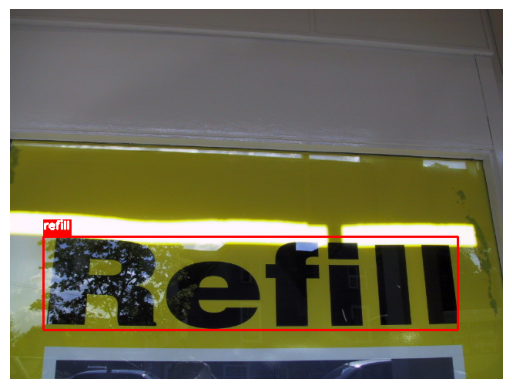

In [6]:
def plot_image_with_bbs(img_path, bbs, labels):

    # 1️⃣ ĐỌC ẢNH VÀ CHUYỂN MÀU
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2️⃣ VẼ CÁC KHUNG CHỮ NHẬT (BOUNDING BOXES)
    # duyệt qua từng bbox trong ảnh
    for idx, bb in enumerate(bbs):
        start_point = (int(bb[0]), int(bb[1]))
        # toạ độ góc trên bên trái (x, y)
        end_point = (int(bb[0] + bb[2]), int(bb[1] + bb[3]))  # góc dưới bên phải (x + w, y + h)
        color = (255, 0, 0)                        # màu khung: đỏ (RGB)
        thickness = 2                              # độ dày viền
        img = cv2.rectangle(img, start_point, end_point, color, thickness)  # vẽ khung chữ nhật


        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.5
        font_color = (255, 255, 255)
        line_type = 2
        text_thickness = 2
        label = labels[idx]
        text_size, _ = cv2.getTextSize(label, font, font_scale, text_thickness)
        # Xác định vị trí nền (background) cho nhãn text
        label_background_start = (int(bb[0]), int(bb[1] - text_size[1] - 10))
        label_background_end = (int(bb[0] + text_size[0]), int(bb[1]))
        img = cv2.rectangle(
            img, label_background_start, label_background_end, color, cv2.FILLED
        )

        # Vẽ chữ label lên nền vừa tạo
        cv2.putText(
            img,
            label,
            (int(bb[0]), int(bb[1] - 10)),
            font,
            font_scale,
            font_color,
            text_thickness,
            line_type,
        )
# 4️⃣ HIỂN THỊ ẢNH
    plt.imshow(img)
    plt.axis("off")
    plt.show()


i = random.randint(0, len(img_paths))
plot_image_with_bbs(img_paths[i], bboxes[i], img_labels[i])

### Lưu tất cả các hộp giới hạn dưới dạng một bộ dữ liệu mới

In [7]:
def split_bounding_boxes(img_paths, img_labels, bboxes, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    labels = []  # List to store labels

 # 1️⃣ DUYỆT TỪNG ẢNH GỐC TRONG DATASET
    for img_path, img_label, bbs in zip(img_paths, img_labels, bboxes):
        img = Image.open(img_path)

         # 2️⃣ DUYỆT QUA TỪNG VÙNG CHỮ (bounding box) TRONG ẢNH
        for label, bb in zip(img_label, bbs):
            # Crop image
            cropped_img = img.crop((bb[0], bb[1], bb[0] + bb[2], bb[1] + bb[3]))

            # Nếu < 35 → ảnh quá tối (đen gần như toàn bộ)
            # Nếu > 220 → ảnh quá sáng (trắng toàn bộ)
            if np.mean(cropped_img) < 35 or np.mean(cropped_img) > 220:
                continue

            # 4️⃣ BỎ ẢNH QUÁ NHỎ (NHIỄU)
            if cropped_img.size[0] < 10 or cropped_img.size[1] < 10:
                continue

            # 5️⃣ LƯU ẢNH CẮT ĐƯỢC
            filename = f"{count:06d}.jpg"
            cropped_img.save(os.path.join(save_dir, filename))

            new_img_path = os.path.join(save_dir, filename)

            label = new_img_path + "\t" + label

            labels.append(label)  # Append label to the list

            count += 1
    # 6️⃣ THÔNG BÁO KẾT QUẢ
    print(f"Created {count} images")

     # 7️⃣ GHI FILE NHÃN RA labels.txt
    with open(os.path.join(save_dir, "labels.txt"), "w") as f:
        for label in labels:
            f.write(f"{label}\n")

In [8]:
save_dir = "/content/drive/MyDrive/TGMT_CK/ocr_dataset"
split_bounding_boxes(img_paths, img_labels, bboxes, save_dir)

Created 1088 images


## 3. Read dataset

In [9]:
root_dir = save_dir

img_paths = []
labels = []

# Read labels from text file
with open(os.path.join(root_dir, "labels.txt"), "r") as f:
    for label in f:
        labels.append(label.strip().split("\t")[1])        # tách theo ký tự tab "\t"
        img_paths.append(label.strip().split("\t")[0])     # phần 1 -> đường dẫn ảnh, phần 2-> nhãn text

print(f"Total images: {len(img_paths)}")

Total images: 1088


## 4. Chuẩn bị từ vựng

In [10]:
# Tạo bảng ký tự + blank
letters = [char.split(".")[0].lower() for char in labels]
letters = "".join(letters)
letters = sorted(list(set(list(letters))))

chars = "".join(letters)
blank_char = "-"  # blank
chars += blank_char
vocab_size = len(chars)

print(f"Vocab: {chars}")
print(f"Vocab size: {vocab_size}")

# Mapping ký tự -> index (blank = 0)
char_to_idx = {char: idx + 1 for idx, char in enumerate(sorted(chars)) if char != blank_char}



Vocab: 0123456789abcdefghijklmnopqrstuvwxyz-
Vocab size: 37


In [11]:
char_to_idx[blank_char] = 0  # blank luôn là 0
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

In [12]:
max_label_len = max([len(label) for label in labels])
max_label_len

14

In [13]:
char_to_idx = {char: idx + 1 for idx, char in enumerate(sorted(chars))}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}


def encode(label, char_to_idx, max_label_len):
    encoded_labels = torch.tensor(
        [char_to_idx[char] for char in label], dtype=torch.long
    )
    label_len = len(encoded_labels)
    padded_labels = F.pad(encoded_labels, (0, max_label_len - label_len), value=0)  # 0 là blank
    return padded_labels, torch.tensor(label_len, dtype=torch.long)

In [14]:
def decode(encoded_sequences, idx_to_char, blank_char="-"):
    decoded_sequences = []

    for seq in encoded_sequences:
        decoded_label = []
        prev_char = None  # To track the previous character

        for token in seq:
            if token != 0:  # Ignore padding (token = 0)
                char = idx_to_char[token.item()]
                # Append the character if it's not a blank or the same as the previous character
                if char != blank_char:
                    if char != prev_char or prev_char == blank_char:
                        decoded_label.append(char)
                prev_char = char  # Update previous character

        decoded_sequences.append("".join(decoded_label))

    # print(f"From {encoded_sequences} to {decoded_sequences}")

    return decoded_sequences

In [15]:
decode([torch.tensor([20, 30, 1, 20, 20, 1])], idx_to_char)

['isi']

## 5. Tạo hàm tiền xử lý dữ liệu

In [ ]:
data_transforms = {
    "train": transforms.Compose(
        [
            # size
            transforms.Resize((100, 420)),
            transforms.ColorJitter(
                # Thay đổi độ sáng, tương phản, bão hòa
                brightness=0.5,
                contrast=0.5,
                saturation=0.5,
            ),
            # chuyển sang grayscale 
            transforms.Grayscale(
                num_output_channels=1,
            ),

            # làm mờ ảnh gaus
            transforms.GaussianBlur(3),
            transforms.RandomAffine(
                # # Biến đổi affine: xoay nhẹ và shear
                degrees=1,
                shear=1,
            ),
            transforms.RandomPerspective(
                distortion_scale=0.3,
                p=0.5,
                interpolation=3,
            ),

            # xoay ảnh +-2 độ 
            transforms.RandomRotation(degrees=2),
            # chuyển PIL sang Tensor 
            transforms.ToTensor(),  
            transforms.Normalize((0.5,), (0.5,)),
        ]
    ),
    "val": transforms.Compose(
        [
            transforms.Resize((100, 420)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    ),
}

## 6. Train, val, test split

In [ ]:
seed = 0                # cố định kết quả random
val_size = 0.1
test_size = 0.1
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    img_paths,
    labels,
    test_size=val_size,
    random_state=seed,
    shuffle=is_shuffle,
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train,                     # 90% dữ liệu ban đầu 
    y_train,                     # nhãn tương ứng 
    test_size=test_size,
    random_state=seed,
    shuffle=is_shuffle,
)

## 7. Tạo bộ dữ liệu pytorch

In [ ]:
class STRDataset(Dataset):
    def __init__(
     self,
        X,                  # Danh sách đường dẫn ảnh
        y,                  # Danh sách nhãn text tương ứng
        char_to_idx,        # Từ điển ánh xạ ký tự → index
        max_label_len,      # Độ dài tối đa của chuỗi label
        label_encoder=None,# Hàm encode label (text → sequence index)
        transform=None,     # Transform tiền xử lý ảnh
    ):
        # Lưu transform (augment + preprocess)
        self.transform = transform

        # Lưu danh sách đường dẫn ảnh
        self.img_paths = X

        # Lưu danh sách nhãn dạng chuỗi (string)
        self.labels = y

        # Bảng ánh xạ ký tự → số (vd: 'a' → 1, 'b' → 2, ...)
        self.char_to_idx = char_to_idx

        # Chiều dài tối đa của label (dùng cho padding / CTC)
        self.max_label_len = max_label_len

        # Hàm encode label thành dạng số
        self.label_encoder = label_encoder

    def __len__(self):
        return len(self.img_paths)
    
    # lấy 1 mẫu theo index
    def __getitem__(self, idx):
        label = self.labels[idx]
        img_path = self.img_paths[idx]
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return None or a placeholder if loading fails
            return None, None, None


        if self.transform:
            img = self.transform(img)

        if self.label_encoder:
            encoded_label, label_len = self.label_encoder(
                label, self.char_to_idx, self.max_label_len
            )
        return img, encoded_label, label_len

## 8. Tạo bộ tải dữ liệu

In [19]:
train_dataset = STRDataset(
    X_train,
    y_train,
    char_to_idx=char_to_idx,
    max_label_len=max_label_len,
    label_encoder=encode,
    transform=data_transforms["train"],
)
val_dataset = STRDataset(
    X_val,
    y_val,
    char_to_idx=char_to_idx,
    max_label_len=max_label_len,
    label_encoder=encode,
    transform=data_transforms["val"],
)
test_dataset = STRDataset(
    X_test,
    y_test,
    char_to_idx=char_to_idx,
    max_label_len=max_label_len,
    label_encoder=encode,
    transform=data_transforms["val"],
)

In [20]:
print(
    f"Train dataset: {len(train_dataset)}",
    f"Val dataset: {len(val_dataset)}",
    f"Test dataset: {len(test_dataset)}",
    sep="\n",
)

Train dataset: 881
Val dataset: 109
Test dataset: 98


In [21]:
train_batch_size = 64
test_batch_size = 64 * 2

train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=test_batch_size,
    shuffle=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=test_batch_size,
    shuffle=False,
)

['libraries', 'befeater', 'profesional', 'traped', 'in', 'to', 'future', 'beardwel', 'clock', 'boundary', '2', 'tesco', 'peter', 'ned', 'orange', 'system', 'when', 'teth', 'inven', 'here', 'lodgings', 'profesional', 'conels', 'mortgages', 'kenedy', 'to', 'become', 'a', 'know', 'chapman', '201', 'xtra', 'for', 'digital', 'programer', 'web', 'strategy', 'these', 'hire', 'and', 'aircraft', 'strategy', 'ian', 'games', 'franklin', 'arena', 'soap', 'do', 'nokia', 'u', 'aspnet', 'ersit', 'report', 'dlr', 'seatrade', 'hofman', 'invent', 'solution', 'frephone', 'stationery', 'bagage', 'red', 'dolar', 'case']


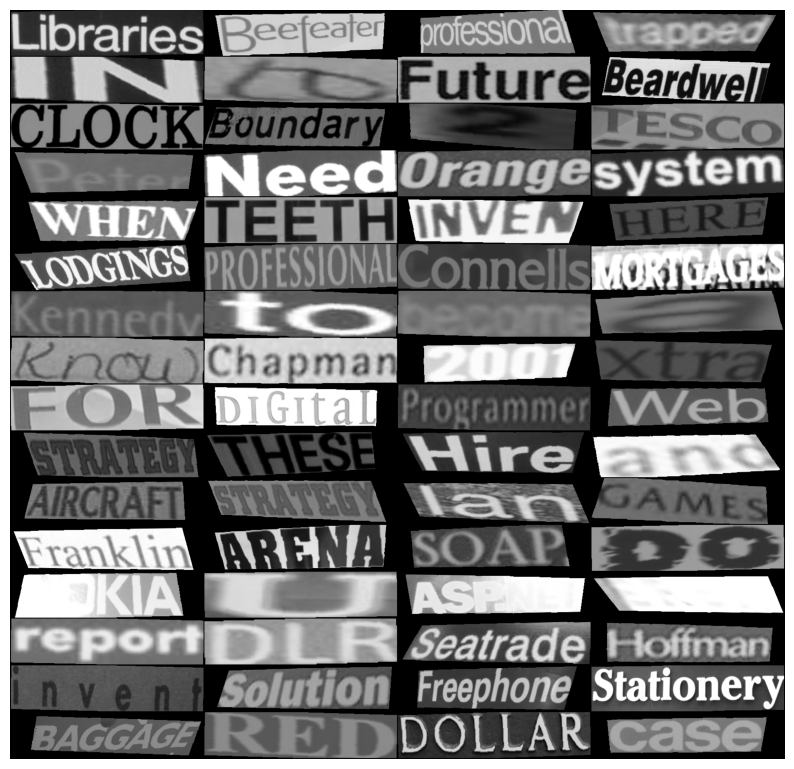

In [22]:
train_features, train_labels, train_lengths = next(iter(train_loader))


# use torchvision to display a grid of images
def show_batch(imgs, labels):
    labels = decode(labels, idx_to_char)
    grid = torchvision.utils.make_grid(imgs, nrow=4, normalize=True)
    plt.figure(figsize=(10, 20))
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.axis("off")
    print(labels)
    plt.show()


show_batch(train_features, train_labels)

## 9. Tạo mô hình

In [ ]:
# định nghĩa mô hình CRNN (CNN + RNN)
class CRNN(nn.Module):
    def __init__(
        self, vocab_size, hidden_size, n_layers, dropout=0.2, unfreeze_layers=3
    ):
        super(CRNN, self).__init__()

        # Tạo ResNet34 pretrained, input là ảnh grayscale (1 channel)   
        backbone = timm.create_model("resnet34", in_chans=1, pretrained=True)
        modules = list(backbone.children())[:-2]
        modules.append(nn.AdaptiveAvgPool2d((1, None)))
        self.backbone = nn.Sequential(*modules)

       # Chỉ unfreeze một vài layer cuối để tránh overfittings
        for parameter in self.backbone[-unfreeze_layers:].parameters():
            parameter.requires_grad = True

        self.mapSeq = nn.Sequential(
            nn.Linear(512, 512), nn.ReLU(), nn.Dropout(dropout)
        )

        self.gru = nn.GRU(
            512,
            hidden_size,
            n_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.layer_norm = nn.LayerNorm(hidden_size * 2)

        self.out = nn.Sequential(
            nn.Linear(hidden_size * 2, vocab_size), nn.LogSoftmax(dim=2)
        )

    @torch.autocast(device_type="cuda")
    def forward(self, x):
        x = self.backbone(x)
        x = x.permute(0, 3, 1, 2)
        x = x.view(x.size(0), x.size(1), -1)  # Flatten the feature map
        x = self.mapSeq(x)
        x, _ = self.gru(x)
        x = self.layer_norm(x)
        x = self.out(x)
        x = x.permute(1, 0, 2)  # Based on CTC

        return x

In [24]:
hidden_size = 256
n_layers = 3
dropout_prob = 0.2
unfreeze_layers = 3
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CRNN(
    vocab_size=vocab_size,
    hidden_size=hidden_size,
    n_layers=n_layers,
    dropout=dropout_prob,
    unfreeze_layers=unfreeze_layers,
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [25]:
model.eval()

dummy_tensor = torch.rand((64, 1, 100, 420)).to(device)

with torch.no_grad():
    output = model(dummy_tensor)

print("Output shape:", output.shape)

Output shape: torch.Size([14, 64, 37])


## 10. Training

In [ ]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    losses = []

    # tắt gradient tiết kiệm bộ nhớ 
    with torch.no_grad():

        # duyệt từng batch trong data
        for idx, (inputs, labels, labels_len) in enumerate(dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            labels_len = labels_len.to(device)

            outputs = model(inputs)
            logits_lens = torch.full(
                size=(outputs.size(1),), fill_value=outputs.size(0), dtype=torch.long
            ).to(device)

            # Chỉ in batch đầu tiên để xem kết quả decode
            if idx == 0:
              print(decode(outputs.permute(1, 0, 2).argmax(2), idx_to_char)[:10])
              print(decode(labels, idx_to_char)[:10])

            loss = criterion(outputs, labels, logits_lens, labels_len)
            losses.append(loss.item())

    loss = sum(losses) / len(losses)

    return loss

In [ ]:
def fit(
    model,
    train_loader,
    val_loader,
    criterion,        # CTC Loss
    optimizer,        # Optimizer
    scheduler,        # LR scheduler
    device,
    epochs,
    max_grad_norm=2,  # Gradient clipping threshold
):
    import time
    import torch
    import torch.nn.functional as F

    train_losses = []  # Lưu train loss từng epoch
    val_losses = []    # Lưu val loss từng epoch

    for epoch in range(epochs):
        start = time.time()
        batch_train_losses = []

        model.train()  # Bật training mode (Dropout, BN)
        for idx, (inputs, labels, labels_len) in enumerate(train_loader):

            # Đưa dữ liệu lên device
            inputs = inputs.to(device)
            labels = labels.to(device)
            labels_len = labels_len.to(device)

            optimizer.zero_grad()  # Reset gradient

            outputs = model(inputs)  # Forward, mong đợi (T, N, C)

            # Nếu output là (N, T, C) thì đổi về (T, N, C)
            if outputs.dim() == 3 and outputs.shape[0] == inputs.shape[0]:
                outputs = outputs.permute(1, 0, 2)

            # Trường hợp đặc biệt T = 1
            elif outputs.dim() == 2:
                outputs = outputs.unsqueeze(0)

            T, N, C = outputs.size()  # T: time, N: batch, C: vocab size

            # Nếu batch lỗi thì bỏ qua
            if labels_len.size(0) != N:
                continue

            # Gộp label thật (bỏ padding) để dùng cho CTC
            target_list = []
            for i in range(N):
                l = int(labels_len[i].item())
                if l > 0:
                    target_list.append(labels[i, :l])

            # Nếu batch không có label hợp lệ
            if len(target_list) == 0:
                targets = torch.empty((0,), dtype=torch.long, device=device)
            else:
                targets = torch.cat(target_list).to(device)

            # Mỗi sample có input length = T
            input_lengths = torch.full(
                size=(N,), fill_value=T, dtype=torch.long
            ).to(device)

            # Log-softmax cho CTC Loss
            log_probs = F.log_softmax(outputs, dim=2)

            # Bỏ batch nếu label dài hơn input
            if torch.any(labels_len > input_lengths):
                continue

            # Bỏ batch nếu label vượt vocab
            if torch.any(targets >= C):
                continue

            # Tính CTC loss
            loss = criterion(log_probs, targets, input_lengths, labels_len)

            # Bỏ batch nếu loss NaN
            if torch.isnan(loss):
                continue

            loss.backward()  # Backprop

            # Gradient clipping (quan trọng với RNN)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            optimizer.step()  # Update weights

            batch_train_losses.append(loss.item())  # Lưu loss batch

        # Train loss trung bình epoch
        train_loss = (
            sum(batch_train_losses) / len(batch_train_losses)
            if batch_train_losses else 0.0
        )
        train_losses.append(train_loss)

        # Validation loss
        val_loss = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)

        # In log epoch
        print(
            f"EPOCH {epoch + 1:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Time: {time.time() - start:.2f}s"
        )

        scheduler.step()  # Update learning rate

    return train_losses, val_losses


In [28]:
epochs = 100
lr = 1e-3
weight_decay = 1e-5
scheduler_step_size = epochs * 0.5

criterion = nn.CTCLoss(
    blank=0,                # blank là 0
    zero_infinity=True,
    reduction="mean",
)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=weight_decay,
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=scheduler_step_size, gamma=0.1
)

In [ ]:
train_losses, val_losses = fit(
    model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs
)

['', '', '', '', '', '', '', '', '', '']
['of', '1809', 'guidex', 'construction', 'unauthorised', 'jeny', '2n', 'fifth', 'sex', 'homogenic']
EPOCH 001 | Train Loss: 4.8963 | Val Loss: 3.8494 | Time: 11.19s
['', '', '', 'e', 'e', '', '', '', '', 'e']
['of', '1809', 'guidex', 'construction', 'unauthorised', 'jeny', '2n', 'fifth', 'sex', 'homogenic']
EPOCH 002 | Train Loss: 3.6200 | Val Loss: 3.7207 | Time: 9.39s
['', '', '', '', '', '', '', '', '', '']
['of', '1809', 'guidex', 'construction', 'unauthorised', 'jeny', '2n', 'fifth', 'sex', 'homogenic']
EPOCH 003 | Train Loss: 3.4900 | Val Loss: 3.5607 | Time: 8.59s
['', '', '', '', '', '', '', '', '', '']
['of', '1809', 'guidex', 'construction', 'unauthorised', 'jeny', '2n', 'fifth', 'sex', 'homogenic']
EPOCH 004 | Train Loss: 3.3722 | Val Loss: 3.4627 | Time: 9.54s
['', '', '', '', '', '', '', '', '', '']
['of', '1809', 'guidex', 'construction', 'unauthorised', 'jeny', '2n', 'fifth', 'sex', 'homogenic']
EPOCH 005 | Train Loss: 3.3432 | Va

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses)
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[1].plot(val_losses, color="orange")
ax[1].set_title("Val Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
plt.show()

## 11. Đánh giá

In [ ]:
val_loss = evaluate(model, val_loader, criterion, device)
test_loss = evaluate(model, test_loader, criterion, device)

print("Evaluation on val/test dataset")
print("Val loss: ", val_loss)
print("Test loss: ", test_loss)

## 12. Dự đoán với Xử lý Hậu kỳ

In [ ]:
def predict(model, img):
    model.eval()
    with torch.no_grad():
        outputs = model(img)
        print(outputs)

def decode_label(encoded_sequences, idx_to_char, blank_char="-"):
    decoded_sequences = []

    for seq in encoded_sequences:
        decoded_label = []
        for idx, token in enumerate(seq):
            if token != 0:
                char = idx_to_char[token.item()]
                if char != blank_char:
                    decoded_label.append(char)

        decoded_sequences.append("".join(decoded_label))

    return decoded_sequences

In [ ]:
# view samples
sample_result = []

for i in range(50):
    idx = np.random.randint(len(val_dataset))
    img, label, label_len = train_dataset[idx]
    img = img.to(device)
    label = label.to(device)
    label = decode_label([label], idx_to_char)[0]
    logits = model(img.unsqueeze(0))

    pred_text = decode(logits.permute(1, 0, 2).argmax(2), idx_to_char)[0]

    sample_result.append((img, label, pred_text))

fig = plt.figure(figsize=(17, 20))
for i in range(50):
    ax = fig.add_subplot(10, 5, i + 1, xticks=[], yticks=[])

    img, label, pred_text = sample_result[i]
    img = img.cpu()
    title = f"Truth: {label} | Pred: {pred_text}"

    ax.imshow(img.permute(1, 2, 0), cmap="gray")
    ax.set_title(title)

plt.show()

### Test dataset

In [ ]:
# view samples
sample_result = []

for i in range(50):
    idx = np.random.randint(len(test_dataset))
    img, label, label_len = train_dataset[idx]
    img = img.to(device)
    label = label.to(device)
    label = decode_label([label], idx_to_char)[0]
    logits = model(img.unsqueeze(0))

    pred_text = decode(logits.permute(1, 0, 2).argmax(2), idx_to_char)[0]

    sample_result.append((img, label, pred_text))

fig = plt.figure(figsize=(17, 20))
for i in range(50):
    ax = fig.add_subplot(10, 5, i + 1, xticks=[], yticks=[])

    img, label, pred_text = sample_result[i]
    img = img.cpu()
    title = f"Truth: {label} | Pred: {pred_text}"

    ax.imshow(img.permute(1, 2, 0), cmap="gray")
    ax.set_title(title)

plt.show()

## 13. Save model

In [ ]:
save_model_path = "/content/drive/My Drive/TGMT_CK/models/ocr_crnn.pt"
torch.save(model.state_dict(), save_model_path)
print(f"✅ Model đã lưu tại: {save_model_path}")